In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
sns.set_theme(style="white")
LOG_DIR = Path("training_logs")

logs = {}

for csv_file in LOG_DIR.glob("*.csv"):

    name = csv_file.stem
    parts = name.split("_")

    lg = int(parts[2][1:])
    nc = int(parts[3][1:])
    ld = int(parts[4][1:])

    logs[(lg, nc, ld)] = pd.read_csv(csv_file)

In [19]:
def plot_metric_grid(metric, latent_dim):

    lambdas = [5, 10, 15]
    critics = [2, 3, 5]

    fig, axes = plt.subplots(
        3,
        3,
        figsize=(14, 12),
        sharex=True
    )

    for r, nc in enumerate(critics):

        for c, lg in enumerate(lambdas):

            ax = axes[r, c]

            df = logs[(lg, nc, latent_dim)]

            ax.plot(
                df["epoch"],
                df[metric],
                linewidth=2
            )

            if r == 0:
                ax.set_title(f"λ={lg}")

            if c == 0:
                ax.set_ylabel(
                    f"n={nc}\n{metric}"
                )

            ax.grid(True)

    fig.suptitle(
        f"{metric} (latent_dim={latent_dim})",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

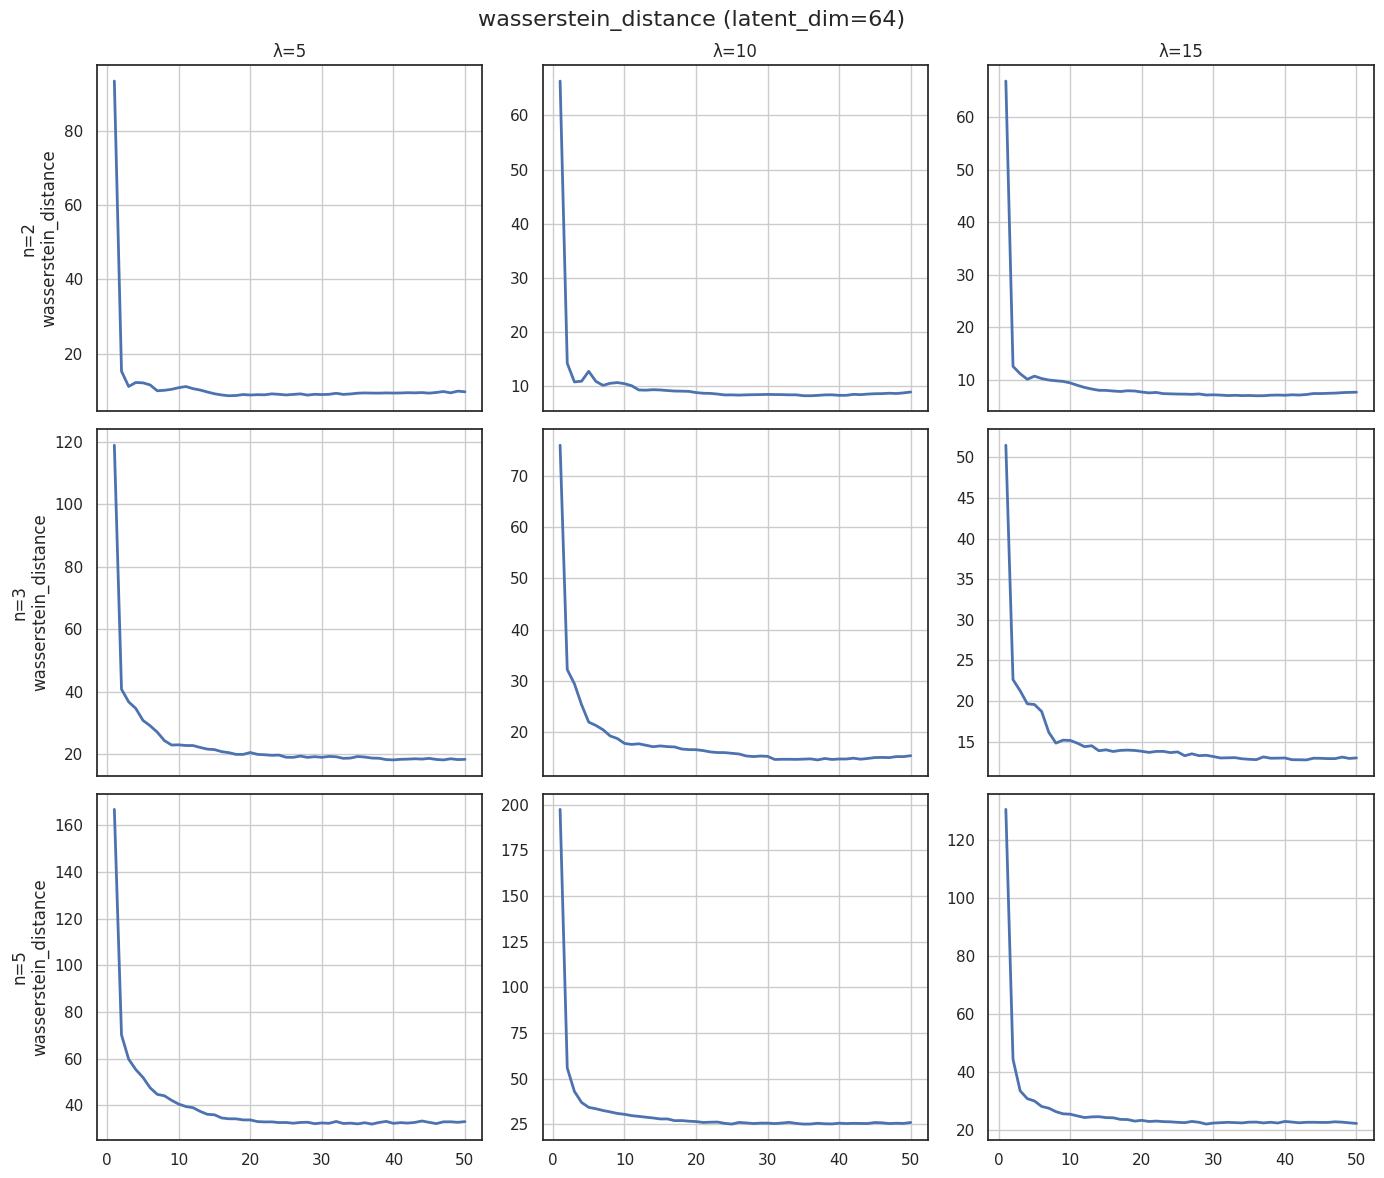

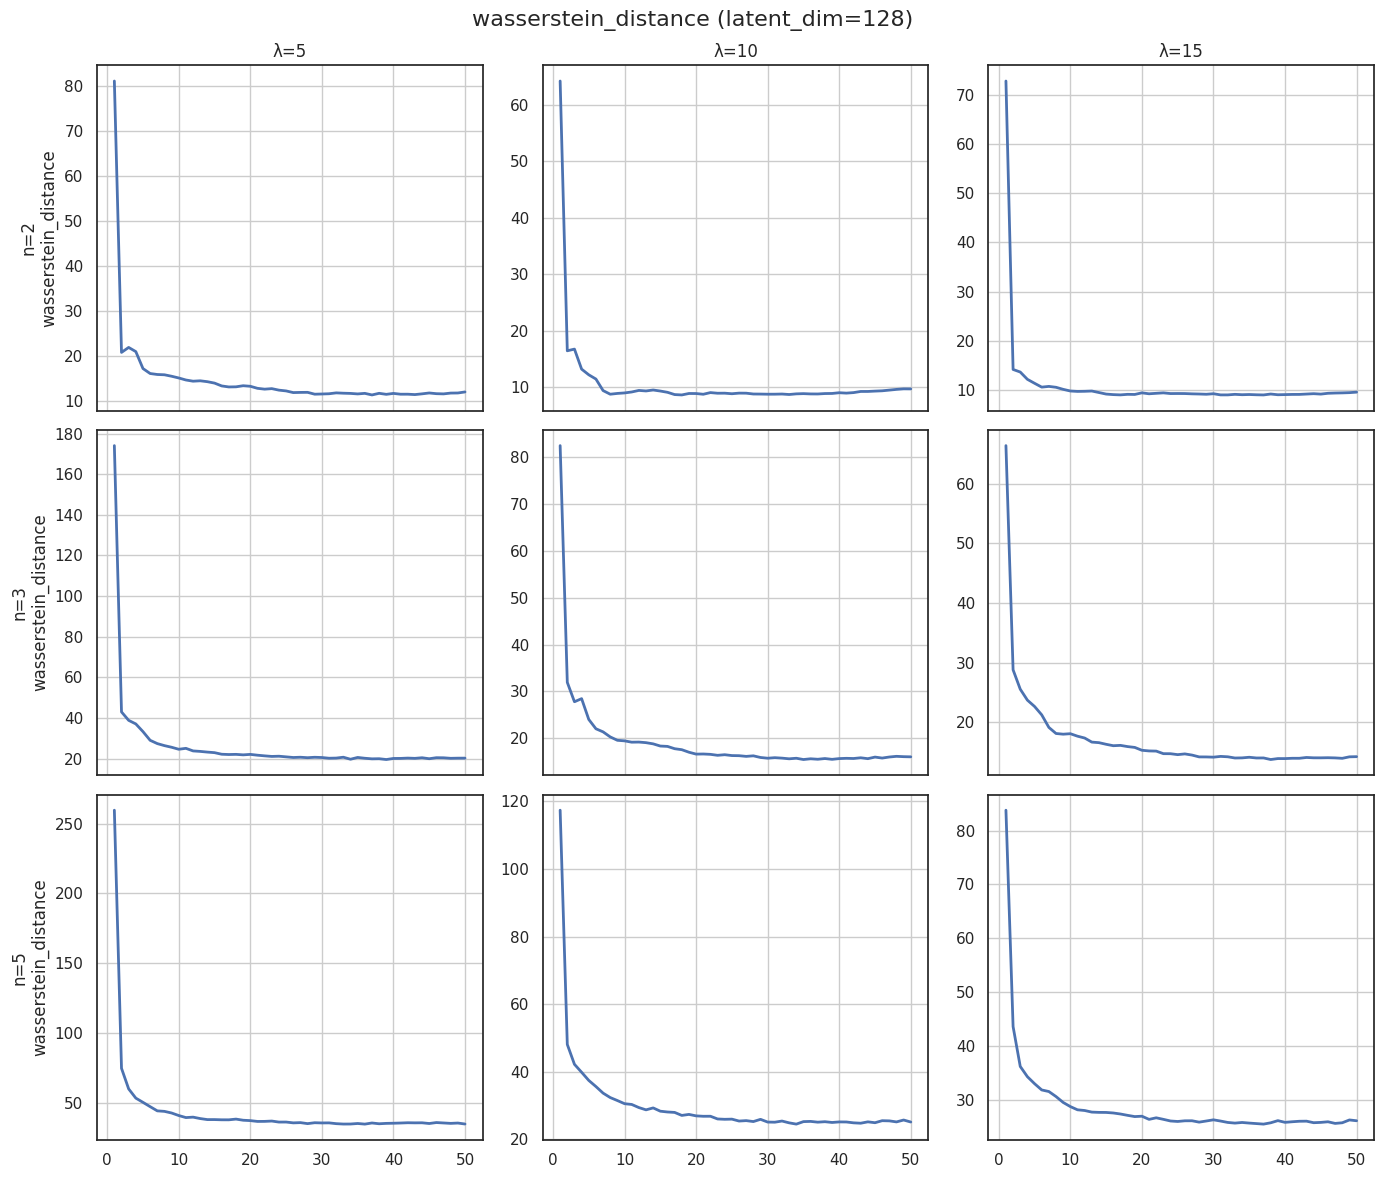

In [20]:
plot_metric_grid(
    "wasserstein_distance",
    latent_dim=64
)

plot_metric_grid(
    "wasserstein_distance",
    latent_dim=128
)

In [21]:
results = pd.read_csv(
    "outputs/wgan_gp_fid_results.csv"
)

display(
    results.sort_values("fid")
)

,lambda_gp,n_critic,latent_dim,fid,cat_score
9,10,3,128,196.9733,0.109479
6,10,2,64,197.7986,0.108276
8,10,3,64,200.7170,0.094228
10,10,5,64,200.9601,0.075003
16,15,5,64,201.9176,0.072260
17,15,5,128,202.7558,0.044037
4,5,5,64,202.8529,0.082293
15,15,3,128,204.2906,0.070344
11,10,5,128,205.5404,0.049441
13,15,2,128,205.6360,0.050153


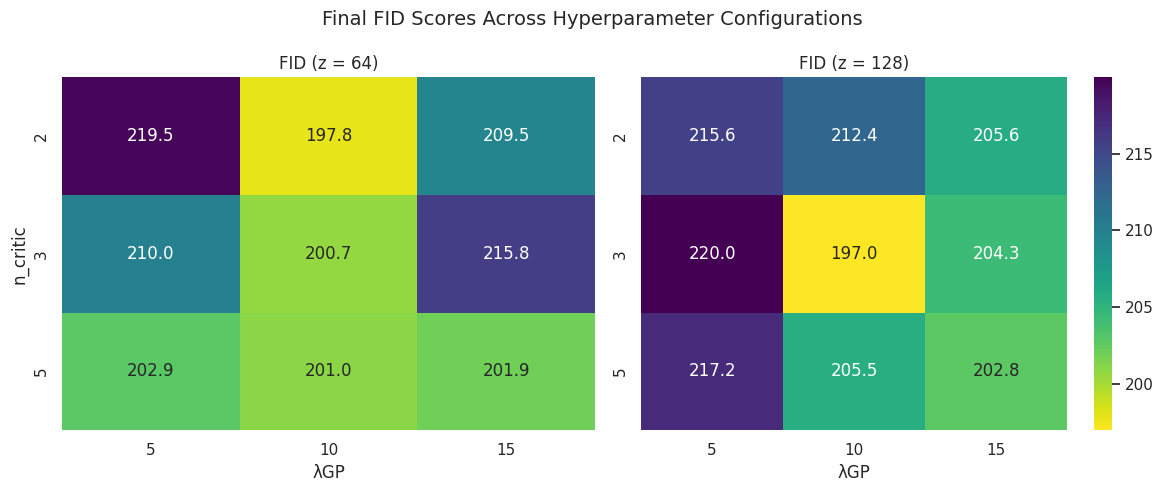

In [23]:
fid64 = (
    results[results["latent_dim"] == 64]
    .pivot(
        index="n_critic",
        columns="lambda_gp",
        values="fid"
    )
)

fid128 = (
    results[results["latent_dim"] == 128]
    .pivot(
        index="n_critic",
        columns="lambda_gp",
        values="fid"
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

vmin = results["fid"].min()
vmax = results["fid"].max()

sns.heatmap(
    fid64,
    annot=True,
    fmt=".1f",
    cmap="viridis_r",
    ax=axes[0],
    vmin=vmin,
    vmax=vmax,
    cbar=False
)

axes[0].set_title("FID (z = 64)")
axes[0].set_xlabel("λGP")
axes[0].set_ylabel("n_critic")

sns.heatmap(
    fid128,
    annot=True,
    fmt=".1f",
    cmap="viridis_r",
    ax=axes[1],
    vmin=vmin,
    vmax=vmax
)

axes[1].set_title("FID (z = 128)")
axes[1].set_xlabel("λGP")
axes[1].set_ylabel("")

plt.suptitle(
    "Final FID Scores Across Hyperparameter Configurations",
    fontsize=14
)

plt.tight_layout()
plt.show()

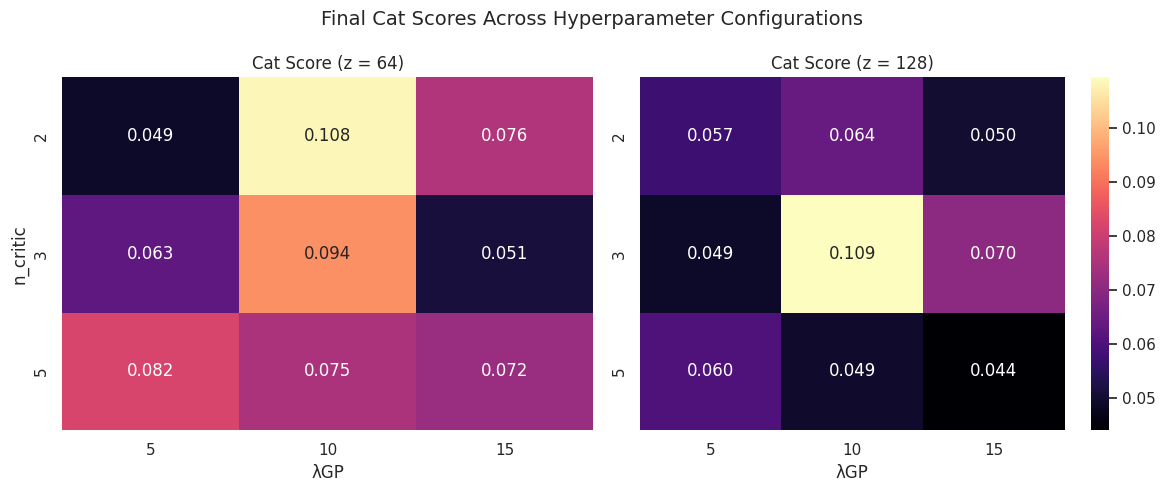

In [24]:
cat64 = (
    results[results["latent_dim"] == 64]
    .pivot(
        index="n_critic",
        columns="lambda_gp",
        values="cat_score"
    )
)

cat128 = (
    results[results["latent_dim"] == 128]
    .pivot(
        index="n_critic",
        columns="lambda_gp",
        values="cat_score"
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

vmin = results["cat_score"].min()
vmax = results["cat_score"].max()

sns.heatmap(
    cat64,
    annot=True,
    fmt=".3f",
    cmap="magma",
    ax=axes[0],
    vmin=vmin,
    vmax=vmax,
    cbar=False
)

axes[0].set_title("Cat Score (z = 64)")
axes[0].set_xlabel("λGP")
axes[0].set_ylabel("n_critic")

sns.heatmap(
    cat128,
    annot=True,
    fmt=".3f",
    cmap="magma",
    ax=axes[1],
    vmin=vmin,
    vmax=vmax
)

axes[1].set_title("Cat Score (z = 128)")
axes[1].set_xlabel("λGP")
axes[1].set_ylabel("")

plt.suptitle(
    "Final Cat Scores Across Hyperparameter Configurations",
    fontsize=14
)

plt.tight_layout()
plt.show()

The best WGAN-GP parameter combination is n_critics = 3, lambda_gp = 10, latent_dim = 128.